# Matrix Computation: NumPy and SymPy

This notebook accompanies the **Compute responsibly** section of Lecture _Why Linear Algebra_. It is a first orientation to matrix computation—not a Python reference manual. Run the cells in order, change small examples, and return here when you need a familiar pattern later in the course.

We will use two complementary packages:

- **NumPy** for efficient numerical computation with floating-point numbers and realistic problems.
- **SymPy** for exact arithmetic, symbolic computation, algebraic verification, and textbook-like displays.

It is common to compute numerically with NumPy and display a small result with SymPy's `Matrix(...)`. That conversion improves the presentation; it does **not** restore precision that floating-point computation has already lost.

### Run the notebook locally or in Colab

Use Jupyter with the `qmcpy` environment, or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/00-why-linear-algebra.ipynb)

In Colab, run the setup cell below once and then continue in order. It installs the course's recorded `classlib` version and TeX support, which may take several minutes. Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "classlib",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
import matplotlib.pyplot as plt
import classlib as cl

%matplotlib inline

cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT

### Shared display helpers

These shared `classlib.nbviz` helpers use SymPy only for textbook-style display. They accept NumPy arrays or SymPy matrices and do not change the underlying calculation.

In [3]:
from classlib.nbviz import show_augmented, show_blocks, show_mat

## 1. Creating vectors and matrices

A vector in $\mathbb{R}^n$ records $n$ numbers. A matrix in $\mathbb{R}^{m\times n}$ is a rectangular array with $m$ rows and $n$ columns. NumPy's `array` is the basic numerical container.

In [4]:
x = np.array([3.0, 2.0])                 # one-dimensional array
row = np.array([[3.0, 2.0]])             # 1 x 2 row vector
column = np.array([[3.0], [2.0]])        # 2 x 1 column vector
A = np.array([[1.0, 0.5], [0.0, 1.0]])

show_mat(x, row, column, A)

Matrix([
[3.0],
[2.0]])

Matrix([[3.0, 2.0]])

Matrix([
[3.0],
[2.0]])

Matrix([
[1.0, 0.5],
[0.0, 1.0]])

A NumPy vector written as `np.array([3, 2])` has shape `(2,)`: it is neither explicitly a row nor explicitly a column. Use a two-dimensional array when that distinction matters.

In [5]:
print("x.shape     =", x.shape)
print("row.shape   =", row.shape)
print("column.shape=", column.shape)
print("A.shape     =", A.shape)

x.shape     = (2,)
row.shape   = (1, 2)
column.shape= (2, 1)
A.shape     = (2, 2)


In [6]:
Z = np.zeros((2, 3))
O = np.ones((2, 3))
I = np.eye(3)
show_mat(Z, O, I)

Matrix([
[0.0, 0.0, 0.0],
[0.0, 0.0, 0.0]])

Matrix([
[1.0, 1.0, 1.0],
[1.0, 1.0, 1.0]])

Matrix([
[1.0, 0.0, 0.0],
[0.0, 1.0, 0.0],
[0.0, 0.0, 1.0]])

SymPy matrices are always two-dimensional and are designed for exact or symbolic work. Integer entries remain exact.

In [7]:
x_exact = Matrix([3, 2])
row_exact = Matrix([[3, 2]])
A_exact = Matrix([[1, sp.Rational(1, 2)], [0, 1]])
Z_exact = sp.zeros(2, 3)
O_exact = sp.ones(2, 3)
I_exact = sp.eye(3)

print("A_exact.shape =", A_exact.shape)
show_mat(A_exact, Z_exact, O_exact, I_exact)

A_exact.shape = (2, 2)


Matrix([
[1, 1/2],
[0,   1]])

Matrix([
[0, 0, 0],
[0, 0, 0]])

Matrix([
[1, 1, 1],
[1, 1, 1]])

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

## 2. Accessing entries

Python starts counting at zero. Thus `A[0, 1]` is the entry in the first row and second column. Slices use `start:stop`, including `start` but excluding `stop`.

In [8]:
A = np.array([[1.0, 2.0, 3.0],
              [4.0, 5.0, 6.0],
              [7.0, 8.0, 9.0]])

print("entry A[0, 1]:", A[0, 1])
print("first row:    ", A[0, :])
print("second column:", A[:, 1])
show_mat(A[:2, 1:])

entry A[0, 1]: 2.0
first row:     [1. 2. 3.]
second column: [2. 5. 8.]


Matrix([
[2.0, 3.0],
[5.0, 6.0]])

In [9]:
A_changed = A.copy()
A_changed[0, 1] = -2
A_changed[:, 2] = 0
show_mat(A_changed)

Matrix([
[1.0, -2.0, 0.0],
[4.0,  5.0, 0.0],
[7.0,  8.0, 0.0]])

SymPy uses similar indexing. Use two-dimensional slices to retain a row or column as a matrix.

In [10]:
S = Matrix([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
S_changed = S.copy()
S_changed[0, 1] = -2
show_mat(S[0, :], S[:, 1], S_changed)

Matrix([[1, 2, 3]])

Matrix([
[2],
[5],
[8]])

Matrix([
[1, -2, 3],
[4,  5, 6],
[7,  8, 9]])

## 3. Matrix arithmetic

For compatible matrices, addition and scalar multiplication work as expected. The crucial NumPy distinction is:

- `A * B` multiplies corresponding entries (**elementwise multiplication**).
- `A @ B` performs **matrix multiplication**.

Use `@` for the linear-algebra products $\mathsf{A}\boldsymbol{x}$ and $\mathsf{A}\mathsf{B}$.

In [11]:
A = np.array([[1.0, 2.0], [3.0, 4.0]])
B = np.array([[2.0, 0.0], [1.0, 2.0]])
x = np.array([1.0, -1.0])

show_mat(A + B, 3 * A, A * B, A @ B, A @ x)

Matrix([
[3.0, 2.0],
[4.0, 6.0]])

Matrix([
[3.0,  6.0],
[9.0, 12.0]])

Matrix([
[2.0, 0.0],
[3.0, 8.0]])

Matrix([
[ 4.0, 4.0],
[10.0, 8.0]])

Matrix([
[-1.0],
[-1.0]])

In [12]:
show_mat(A.T, B @ A, A @ B)

Matrix([
[1.0, 3.0],
[2.0, 4.0]])

Matrix([
[2.0,  4.0],
[7.0, 10.0]])

Matrix([
[ 4.0, 4.0],
[10.0, 8.0]])

The transpose $\mathsf{A}^{\mathsf T}$ exchanges rows and columns. Matrix multiplication usually does not commute: here $\mathsf{B}\mathsf{A}\ne \mathsf{A}\mathsf{B}$. In SymPy, `*` means matrix multiplication when both operands are matrices.

In [13]:
A_exact = Matrix([[1, 2], [3, 4]])
B_exact = Matrix([[2, 0], [1, 2]])
x_exact = Matrix([1, -1])
show_mat(
    A_exact + B_exact,
    3 * A_exact,
    A_exact * x_exact,
    A_exact * B_exact,
    A_exact.T,
)

Matrix([
[3, 2],
[4, 6]])

Matrix([
[3,  6],
[9, 12]])

Matrix([
[-1],
[-1]])

Matrix([
[ 4, 4],
[10, 8]])

Matrix([
[1, 3],
[2, 4]])

## 4. Common matrix construction utilities

`reshape` changes the arrangement without changing the entries. Stacking and concatenation assemble larger arrays from compatible pieces.

In [14]:
numbers = np.arange(1, 7)
R = numbers.reshape(2, 3)
u = np.array([[1.0], [2.0]])
v = np.array([[3.0], [4.0]])

show_mat(R, np.hstack((u, v)), np.vstack((u.T, v.T)))

Matrix([
[1, 2, 3],
[4, 5, 6]])

Matrix([
[1.0, 3.0],
[2.0, 4.0]])

Matrix([
[1.0, 2.0],
[3.0, 4.0]])

In [15]:
top = np.array([[1.0, 2.0]])
bottom = np.array([[3.0, 4.0]])
D = np.diag([2.0, 5.0, 8.0])

show_mat(np.concatenate((top, bottom), axis=0), D)
print("diagonal entries:", np.diag(D))

Matrix([
[1.0, 2.0],
[3.0, 4.0]])

Matrix([
[2.0, 0.0, 0.0],
[0.0, 5.0, 0.0],
[0.0, 0.0, 8.0]])

diagonal entries: [2. 5. 8.]


In SymPy, `row_join` places matrices side by side and `col_join` places them one above another.

In [16]:
u_exact = Matrix([1, 2])
v_exact = Matrix([3, 4])
show_mat(
    u_exact.row_join(v_exact),
    u_exact.T.col_join(v_exact.T),
    sp.diag(2, 5, 8),
)

Matrix([
[1, 3],
[2, 4]])

Matrix([
[1, 2],
[3, 4]])

Matrix([
[2, 0, 0],
[0, 5, 0],
[0, 0, 8]])

In [17]:
show_blocks(
    [sp.eye(2), Matrix([1, 2])],
    [Matrix([[3, 4]]), Matrix([[5]])],
)

Matrix([
[Matrix([
[1, 0],
[0, 1]]), Matrix([
[1],
[2]])],
[         Matrix([[3, 4]]),       Matrix([[5]])]])

## 5. Solving linear systems

Consider $\mathsf{A}\boldsymbol{x}=\boldsymbol{b}$. NumPy's `np.linalg.solve(A, b)` computes a numerical solution of a square system.

In [18]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
b = np.array([9.0, 8.0])
x = np.linalg.solve(A, b)

print("solution x =", x)
show_augmented(A, b)

solution x = [2. 3.]


<IPython.core.display.Math object>

In [19]:
A_exact = Matrix([[3, 1], [1, 2]])
b_exact = Matrix([9, 8])
x_exact = A_exact.LUsolve(b_exact)
x_exact

Matrix([
[2],
[3]])

Mathematically, $\boldsymbol{x}=\mathsf{A}^{-1}\boldsymbol{b}$ when $\mathsf{A}^{-1}$ exists. Computationally, use `solve` or `LUsolve`: explicitly forming the inverse generally costs more and can introduce more numerical error.

In [20]:
x_from_inverse = np.linalg.inv(A) @ b
print("solve result:  ", x)
print("inverse result:", x_from_inverse)

solve result:   [2. 3.]
inverse result: [2. 3.]


## 6. Determinant, inverse, and rank

For a square matrix, the **determinant** helps detect whether the associated transformation is reversible. The **rank** counts independent directions of action or independent information. An **inverse** reverses the action of an invertible square matrix.

In [21]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
print("determinant:", np.linalg.det(A))
print("rank:       ", np.linalg.matrix_rank(A))
show_mat(np.linalg.inv(A))

determinant: 5.000000000000001
rank:        2


Matrix([
[ 0.4, -0.2],
[-0.2,  0.6]])

In [22]:
A_exact = Matrix([[3, 1], [1, 2]])
print("determinant:", A_exact.det())
print("rank:       ", A_exact.rank())
show_mat(A_exact.inv())

determinant: 5
rank:        2


Matrix([
[ 2/5, -1/5],
[-1/5,  3/5]])

## 7. Exact arithmetic versus floating point

Computers store most real numbers using finite-precision approximations. NumPy's floating-point arithmetic is fast and appropriate for realistic numerical work. SymPy can preserve rational numbers exactly, which is valuable for demonstrations and algebraic checks.

In [23]:
third_float = np.float64(1) / 3
third_exact = sp.Rational(1, 3)

print("NumPy 1/3:       ", format(third_float, ".20f"))
print("NumPy 3*(1/3)-1:", 3 * third_float - 1)
third_exact, 3 * third_exact - 1

NumPy 1/3:        0.33333333333333331483
NumPy 3*(1/3)-1: 0.0


(1/3, 0)

Now convert an already approximate NumPy value into a SymPy matrix. The display changes, but the stored approximation does not become the exact rational number $1/3$.

In [24]:
approximate_matrix = Matrix(np.array([[third_float]]))
exact_matrix = Matrix([[third_exact]])
show_mat(approximate_matrix, exact_matrix)
print("entries are exactly equal:", approximate_matrix[0, 0] == exact_matrix[0, 0])

Matrix([[0.333333333333333]])

Matrix([[1/3]])

entries are exactly equal: False


## 8. Least squares

Lecture 00 represents a fitted line $y\approx c_0+c_1t$ as an overdetermined system $\mathsf{A}\boldsymbol{c}\approx\boldsymbol{b}$. Usually no coefficient vector fits every data point exactly. `np.linalg.lstsq` finds the least-squares solution $\widehat{\boldsymbol{c}}$ that minimizes the Euclidean residual norm

$$
\lVert \mathsf{A}\boldsymbol{c}-\boldsymbol{b}\rVert_2.
$$

In [25]:
t = np.array([0.0, 1.0, 2.0, 3.0])
b = np.array([1.0, 2.0, 2.0, 4.0])
A = np.column_stack((np.ones_like(t), t))

c, squared_residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
fitted = A @ c
residual = b - fitted

print("fitted coefficients [c0, c1]:", c)
print("residual vector:             ", residual)
print("residual norm:               ", np.linalg.norm(residual))
show_mat(A, c, residual)

fitted coefficients [c0, c1]: [0.9 0.9]
residual vector:              [ 0.1  0.2 -0.7  0.4]
residual norm:                0.8366600265340757


Matrix([
[1.0, 0.0],
[1.0, 1.0],
[1.0, 2.0],
[1.0, 3.0]])

Matrix([
[0.9],
[0.9]])

Matrix([
[ 0.1],
[ 0.2],
[-0.7],
[ 0.4]])

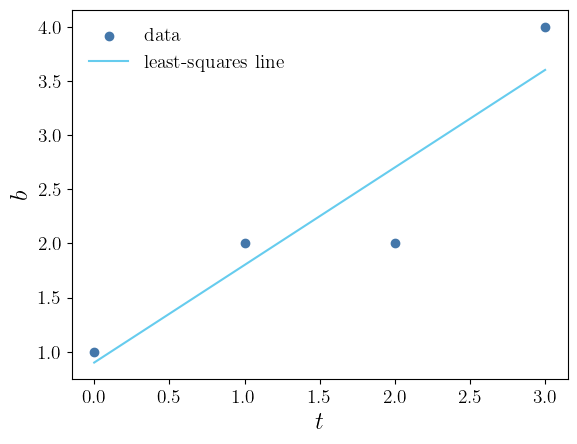

In [26]:
plt.scatter(t, b, color=colors["blue"], label="data")
plt.plot(t, fitted, color=colors["cyan"], label="least-squares line")
plt.xlabel(r"$t$")
plt.ylabel(r"$b$")
plt.legend(frameon=False);

## 9. Compute responsibly

Reliable computation requires more than obtaining an answer:

1. Prefer a solver such as `solve` or `lstsq` to explicitly forming an inverse.
2. Remember that floating-point results are approximations.
3. Mathematically equivalent formulas can behave differently in finite precision.
4. Check matrix shapes before multiplying or stacking arrays.
5. Check a result with a residual such as $\lVert \mathsf{A}\boldsymbol{x}-\boldsymbol{b}\rVert_2$.

In [27]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
b = np.array([9.0, 8.0])
x = np.linalg.solve(A, b)

print("A.shape:      ", A.shape)
print("x.shape:      ", x.shape)
print("b.shape:      ", b.shape)
print("residual norm:", np.linalg.norm(A @ x - b))

A.shape:       (2, 2)
x.shape:       (2,)
b.shape:       (2,)
residual norm: 0.0


Two algebraically equivalent formulas from Lecture 00 illustrate catastrophic cancellation. The rationalized form avoids subtracting nearly equal floating-point numbers.

In [28]:
small = 1.23456789 * np.array([1e-6, 1e-7, 1e-8])
direct = np.sqrt(1 + small**2) - 1
rationalized = small**2 / (np.sqrt(1 + small**2) + 1)

np.column_stack((small, direct, rationalized))

array([[1.23456789e-06, 7.62057084e-13, 7.62078938e-13],
       [1.23456789e-07, 7.54951657e-15, 7.62078938e-15],
       [1.23456789e-08, 0.00000000e+00, 7.62078938e-17]])

The condition number previews sensitivity: a large value warns that small changes in the data may produce much larger changes in the solution. Conditioning is a property of the mathematical problem; reliable software cannot remove it.

In [29]:
well_conditioned = np.array([[3.0, 1.0], [1.0, 2.0]])
nearly_singular = np.array([[1.0, 1.0], [1.0, 1.000001]])

print("condition number, first matrix: ", np.linalg.cond(well_conditioned))
print("condition number, nearly singular:", np.linalg.cond(nearly_singular))

condition number, first matrix:  2.6180339887498953
condition number, nearly singular: 4000002.0002134116


### A habit to keep

Before trusting a computed answer, ask: Is the mathematical problem well posed? Is it sensitive to its data? Is the algorithm appropriate and efficient? Do the shapes match? Is the residual small?

Throughout MATH 332, use computation to explore and verify linear algebra—not as a substitute for understanding why a method works.